# EDGE AI Battery Monitoring — SOC Estimation (Comparative Study)

**Goal:** Estimate live State of Charge (SOC, 0-100%) from voltage/current/temperature, using 3 models suited for eventual ESP32-S3 deployment via TFLite Micro.

**Models compared:**
1. Random Forest (classical ML baseline, windowed statistical features)
2. MLP / Feedforward Neural Network (flattened window, TFLite Micro friendly)
3. LSTM (sequence model, best fit for SOC's inherently time-dependent nature)

**Data:** `timeseries_soc_FINAL.csv` — coulomb-counted SOC ground truth per timestep, extracted from NASA `.mat` battery cycling data (32 batteries, cleaned).

**Split strategy:** by *battery*, not by cycle — some whole batteries are held out for testing, so the models are evaluated on batteries never seen in training. This is stricter (and more honest) than a random row-level split, which would leak information between cycles of the same battery.


In [8]:
! pip install tensorflow scikit-learn

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.4.0-cp312-cp312-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.83.1-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Everything imported successfully")
print("TensorFlow:", tf.__version__)

Everything imported successfully
TensorFlow: 2.21.0


## 1. Load data

In [10]:
df = pd.read_csv('timeseries_soc_FINAL.csv')
print(df.shape)
print(df['battery_id'].nunique(), 'batteries')
df.head()


(738908, 8)
32 batteries


,battery_id,cycle,t_s,voltage,current,temperature,soc,cycle_capacity_Ah
0,B0005,1,0.000,4.191492,-0.004902,24.330034,100.000000,1.856487
1,B0005,1,16.781,4.190749,-0.001478,24.325993,99.999199,1.856487
2,B0005,1,35.703,3.974871,-2.012528,24.389085,99.714095,1.856487
3,B0005,1,53.781,3.951717,-2.013979,24.544752,99.169524,1.856487
4,B0005,1,71.922,3.934352,-2.011144,24.731385,98.623243,1.856487


## 2. Resample to a uniform time grid

NASA's logger sampled at an irregular interval (~9-14s median, varies by battery). Your ESP32-S3 will sample at a fixed rate in deployment, so we resample every cycle onto a uniform grid (default: every 10s) via linear interpolation, before building windows.


In [12]:
def resample_cycle(g, dt=10.0):
    g = g.sort_values('t_s')
    t_max = g['t_s'].max()
    new_t = np.arange(0, t_max, dt)
    if len(new_t) < 5:
        return None
    out = pd.DataFrame({'t_s': new_t})
    for col in ['voltage', 'current', 'temperature', 'soc']:
        out[col] = np.interp(new_t, g['t_s'], g[col])
    out['battery_id'] = g['battery_id'].iloc[0]
    out['cycle'] = g['cycle'].iloc[0]
    return out

resampled = []
for (b, c), g in df.groupby(['battery_id', 'cycle']):
    r = resample_cycle(g)
    if r is not None:
        resampled.append(r)

res_df = pd.concat(resampled, ignore_index=True)
print('Resampled shape:', res_df.shape)
res_df.to_csv('resampled_soc.csv', index=False)


Resampled shape: (865594, 7)


## 3. Battery-level train/test split

Holding out entire batteries (not just cycles) for testing gives an honest estimate of how the model generalizes to a battery it has never seen — the real deployment scenario.


In [13]:
batteries = sorted(res_df['battery_id'].unique())
print(len(batteries), 'batteries total')

rng = np.random.RandomState(42)
shuffled = rng.permutation(batteries)
n_test = max(1, int(len(batteries) * 0.2))
test_batteries = set(shuffled[:n_test])
train_batteries = set(shuffled[n_test:])

print('Test batteries (held out):', sorted(test_batteries))
print('Train batteries:', len(train_batteries))


32 batteries total
Test batteries (held out): [np.str_('B0029'), np.str_('B0030'), np.str_('B0038'), np.str_('B0040'), np.str_('B0047'), np.str_('B0054')]
Train batteries: 26


## 4. Build sliding windows

Each model sees a **window** of the last `WINDOW` timesteps (voltage, current, temperature) and predicts the SOC at the current timestep. `WINDOW=12` with a 10s grid = 120 seconds of lookback — adjust based on your ESP32's sampling rate and available RAM.


In [14]:
WINDOW = 12  # number of past timesteps in each input window

def make_windows(sub_df, window=WINDOW):
    X, y = [], []
    for (b, c), g in sub_df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        v = g['voltage'].values
        i = g['current'].values
        t = g['temperature'].values
        soc = g['soc'].values
        for k in range(window, len(g)):
            X.append(np.stack([v[k-window:k], i[k-window:k], t[k-window:k]], axis=1))
            y.append(soc[k])
    return np.array(X), np.array(y)

train_df = res_df[res_df['battery_id'].isin(train_batteries)]
test_df = res_df[res_df['battery_id'].isin(test_batteries)]

print('Building training windows...')
X_train, y_train = make_windows(train_df)
print('Building test windows...')
X_test, y_test = make_windows(test_df)

print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test:', X_test.shape, ' y_test:', y_test.shape)


Building training windows...
Building test windows...
X_train: (724452, 12, 3)  y_train: (724452,)
X_test: (110854, 12, 3)  y_test: (110854,)


## 5. Normalize inputs

Fit the scaler on **training data only** to avoid leaking test-set statistics.


In [15]:
mean = X_train.reshape(-1, 3).mean(axis=0)
std = X_train.reshape(-1, 3).std(axis=0)

X_train_n = (X_train - mean) / std
X_test_n = (X_test - mean) / std

print('Feature means (V, I, T):', mean)
print('Feature stds  (V, I, T):', std)


Feature means (V, I, T): [ 3.42726816 -1.59422595 26.97717872]
Feature stds  (V, I, T): [ 0.29620104  1.08795212 13.13748771]


## 6. Model 1 — Random Forest (classical ML baseline)

Uses engineered per-window statistics (mean/min/max/last value/delta) rather than the raw sequence, since tree ensembles don't natively exploit sequence order.


In [16]:
def flatten_stats(X):
    feats = []
    for ch in range(X.shape[2]):
        c = X[:, :, ch]
        feats += [c.mean(axis=1), c.min(axis=1), c.max(axis=1), c[:, -1], c[:, -1] - c[:, 0]]
    return np.stack(feats, axis=1)

X_train_feat = flatten_stats(X_train_n)
X_test_feat = flatten_stats(X_test_n)

rf = RandomForestRegressor(n_estimators=200, max_depth=14, n_jobs=-1, random_state=42)
rf.fit(X_train_feat, y_train)

rf_pred = rf.predict(X_test_feat)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest -> MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.4f}')


Random Forest -> MAE: 3.335  RMSE: 5.373  R2: 0.9692


## 7. Model 2 — MLP (Feedforward Neural Network)

Flattens the window into a single vector. Simple, fast, and directly convertible to TFLite Micro for ESP32-S3.


In [17]:
X_train_flat = X_train_n.reshape(len(X_train_n), -1)
X_test_flat = X_test_n.reshape(len(X_test_n), -1)

mlp = keras.Sequential([
    keras.layers.Input(shape=(X_train_flat.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])
mlp.compile(optimizer='adam', loss='mse')

history_mlp = mlp.fit(
    X_train_flat, y_train,
    validation_split=0.1,
    epochs=30, batch_size=512, verbose=1
)

mlp_pred = mlp.predict(X_test_flat, verbose=0).flatten()
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_r2 = r2_score(y_test, mlp_pred)
print(f'MLP -> MAE: {mlp_mae:.3f}  RMSE: {mlp_rmse:.3f}  R2: {mlp_r2:.4f}')


Epoch 1/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 266.9025 - val_loss: 309.1887
Epoch 2/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 34.2112 - val_loss: 178.4737
Epoch 3/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 31.1015 - val_loss: 147.8672
Epoch 4/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 29.0032 - val_loss: 125.9819
Epoch 5/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 27.1815 - val_loss: 113.3960
Epoch 6/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 25.5963 - val_loss: 119.1162
Epoch 7/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 24.3006 - val_loss: 132.7880
Epoch 8/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 23.2503 - val_loss: 157.5054
Epoch 9/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 22.3509 - val_loss: 170.7483
Epoch 10/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 21.3710 - val_loss: 194.2210
Epoch 11/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 20.2964 - val_loss: 198.3

## 8. Model 3 — LSTM (sequence model)

Takes the raw (voltage, current, temperature) sequence directly, without manual feature engineering — best suited to SOC since it's inherently a time-dependent quantity.


In [18]:
lstm = keras.Sequential([
    keras.layers.Input(shape=(X_train_n.shape[1], X_train_n.shape[2])),
    keras.layers.LSTM(32),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')

history_lstm = lstm.fit(
    X_train_n, y_train,
    validation_split=0.1,
    epochs=30, batch_size=512, verbose=1
)

lstm_pred = lstm.predict(X_test_n, verbose=0).flatten()
lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_r2 = r2_score(y_test, lstm_pred)
print(f'LSTM -> MAE: {lstm_mae:.3f}  RMSE: {lstm_rmse:.3f}  R2: {lstm_r2:.4f}')


Epoch 1/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 272.5460 - val_loss: 219.9139
Epoch 2/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 24.7807 - val_loss: 214.2156
Epoch 3/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 22.8077 - val_loss: 273.9931
Epoch 4/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 21.9333 - val_loss: 284.9652
Epoch 5/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 21.2377 - val_loss: 318.6153
Epoch 6/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 20.6848 - val_loss: 338.5194
Epoch 7/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 20.1388 - val_loss: 377.1223
Epoch 8/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 19.4766 - val_loss: 380.7783
Epoch 9/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 18.9130 - val_loss: 398.0110
Epoch 10/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 18.2607 - val_loss: 450.8988
Epoch 11/30
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 17.

## 9. Comparative results

In [19]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'MLP', 'LSTM'],
    'MAE (%)': [rf_mae, mlp_mae, lstm_mae],
    'RMSE (%)': [rf_rmse, mlp_rmse, lstm_rmse],
    'R2': [rf_r2, mlp_r2, lstm_r2],
    'Params/Nodes': [rf.n_estimators, mlp.count_params(), lstm.count_params()]
})
results


,Model,MAE (%),RMSE (%),R2,Params/Nodes
0,Random Forest,3.334830,5.372840,0.969151,200
1,MLP,6.566236,10.686908,0.877949,1729
2,LSTM,6.386562,11.957501,0.847202,5153


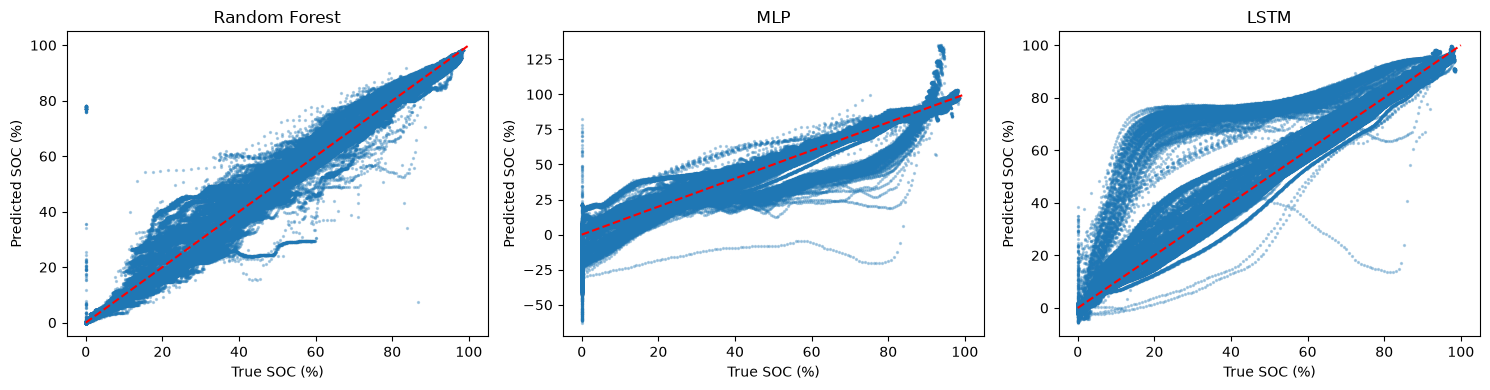

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [('Random Forest', rf_pred), ('MLP', mlp_pred), ('LSTM', lstm_pred)]):
    ax.scatter(y_test, pred, s=2, alpha=0.3)
    ax.plot([0, 100], [0, 100], 'r--')
    ax.set_xlabel('True SOC (%)')
    ax.set_ylabel('Predicted SOC (%)')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('soc_model_comparison.png', dpi=120)
plt.show()


## 10. Edge deployment notes (ESP32-S3)

- **MLP and LSTM** convert directly to TFLite Micro (`tf.lite.TFLiteConverter`), then to a `.tflite` file, then to a C byte array for flashing.
- **Random Forest** doesn't have a native TFLite path — export it as C code instead (e.g. via `emlearn` or `m2cgen`), or use it only as your offline comparative baseline rather than the deployed model.
- Apply **post-training int8 quantization** on the MLP/LSTM before conversion — cuts model size ~4x with usually small accuracy loss, and ESP32-S3 has hardware acceleration for int8 ops.
- Keep `WINDOW` small (12-20 steps) to limit the RAM needed to buffer the input sequence on-device.
- Next notebook: reuse this same pattern (windowing, battery-level split, 3-model comparison) for **SOH** and **RUL**, using the cycle-level summary CSV instead of the timeseries one.


## THE RANDOFM FORREST WINS. BOTH THE OTHERS ARE HEAVILY OVER FIT. SO LETS LEARN THE DATA 

In [21]:
df = pd.read_csv('timeseries_soc_FINAL.csv')
print(df.shape)
df.head()

(738908, 8)


,battery_id,cycle,t_s,voltage,current,temperature,soc,cycle_capacity_Ah
0,B0005,1,0.000,4.191492,-0.004902,24.330034,100.000000,1.856487
1,B0005,1,16.781,4.190749,-0.001478,24.325993,99.999199,1.856487
2,B0005,1,35.703,3.974871,-2.012528,24.389085,99.714095,1.856487
3,B0005,1,53.781,3.951717,-2.013979,24.544752,99.169524,1.856487
4,B0005,1,71.922,3.934352,-2.011144,24.731385,98.623243,1.856487


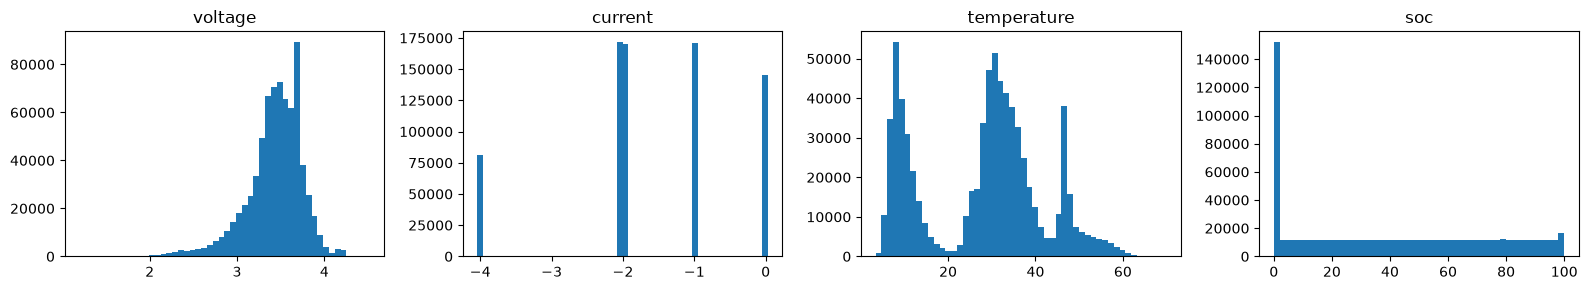

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col in zip(axes, ['voltage', 'current', 'temperature', 'soc']):
    ax.hist(df[col], bins=50)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [23]:
corr = df[['voltage', 'current', 'temperature', 'soc']].corr()
print(corr)

              voltage   current  temperature       soc
voltage      1.000000  0.332802    -0.027042  0.559522
current      0.332802  1.000000    -0.289832 -0.310791
temperature -0.027042 -0.289832     1.000000 -0.180674
soc          0.559522 -0.310791    -0.180674  1.000000


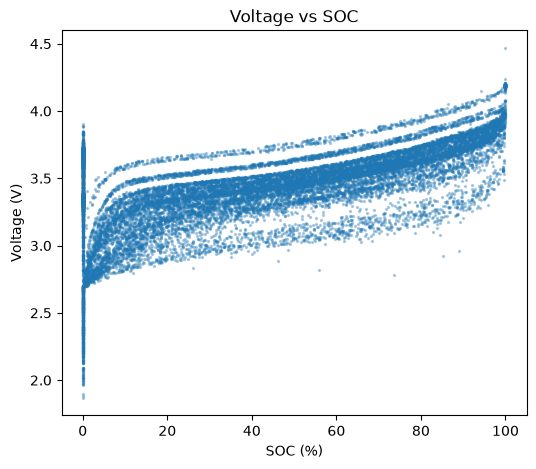

In [24]:
sample = df.sample(20000, random_state=0)  # subsample for a readable scatter
plt.figure(figsize=(6,5))
plt.scatter(sample['soc'], sample['voltage'], s=2, alpha=0.3)
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC')
plt.show()

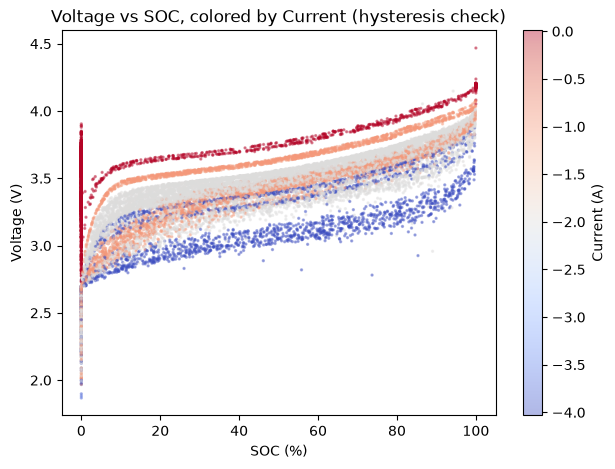

In [25]:
plt.figure(figsize=(7,5))
sc = plt.scatter(sample['soc'], sample['voltage'], c=sample['current'], s=2, alpha=0.4, cmap='coolwarm')
plt.colorbar(sc, label='Current (A)')
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC, colored by Current (hysteresis check)')
plt.show()

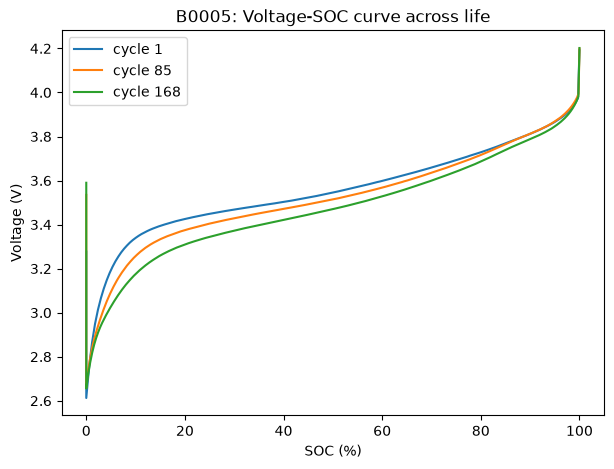

In [26]:
b = 'B0005'
sub = df[df['battery_id']==b]
cycles_available = sorted(sub['cycle'].unique())
picks = [cycles_available[0], cycles_available[len(cycles_available)//2], cycles_available[-1]]

plt.figure(figsize=(7,5))
for c in picks:
    g = sub[sub['cycle']==c]
    plt.plot(g['soc'], g['voltage'], label=f'cycle {c}')
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.title(f'{b}: Voltage-SOC curve across life')
plt.show()

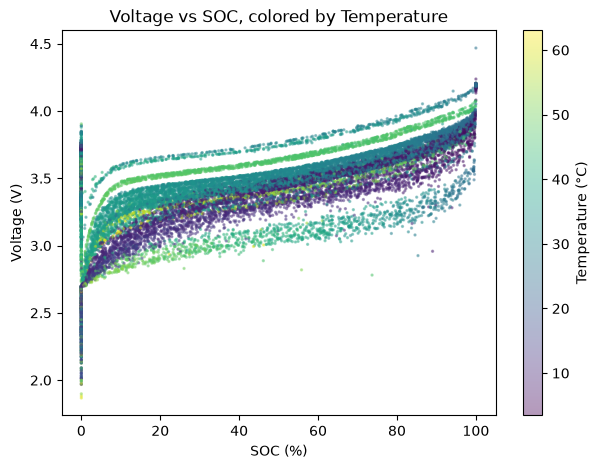

In [27]:
plt.figure(figsize=(7,5))
sc = plt.scatter(sample['soc'], sample['voltage'], c=sample['temperature'], s=2, alpha=0.4, cmap='viridis')
plt.colorbar(sc, label='Temperature (°C)')
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC, colored by Temperature')
plt.show()

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [29]:
df = pd.read_csv('timeseries_soc_FINAL.csv')
print(df.shape)

(738908, 8)


In [30]:
def truncate_after_first_zero(df):
    kept = []
    for (b, c), g in df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        zero_idx = g.index[g['soc'] <= 0]
        if len(zero_idx) > 0:
            first_zero = zero_idx[0]
            g = g.loc[:first_zero]
        kept.append(g)
    return pd.concat(kept, ignore_index=True)

df_clean = truncate_after_first_zero(df)
print("Before:", df.shape, " After:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Before: (738908, 8)  After: (600366, 8)
Rows removed: 138542


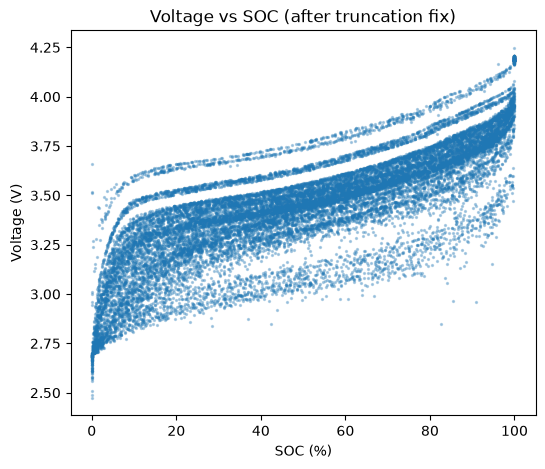

In [31]:
sample = df_clean.sample(20000, random_state=0)
plt.figure(figsize=(6,5))
plt.scatter(sample['soc'], sample['voltage'], s=2, alpha=0.3)
plt.xlabel('SOC (%)'); plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC (after truncation fix)')
plt.show()

In [32]:
protocol_check = df_clean.groupby('battery_id').agg(
    currents=('current', lambda x: sorted(x.round().unique())),
    temp_mean=('temperature', 'mean')
)
print(protocol_check)

                            currents  temp_mean
battery_id                                     
B0005                   [-2.0, -0.0]  32.283889
B0006                   [-2.0, -0.0]  32.229567
B0007                   [-2.0, -0.0]  32.029258
B0018                    [-2.0, 0.0]  30.616126
B0025                    [-4.0, 0.0]  34.691157
B0026                   [-4.0, -0.0]  34.667697
B0027                   [-4.0, -0.0]  37.129170
B0028                    [-2.0, 0.0]  30.320370
B0029                   [-4.0, -0.0]  52.563786
B0030                    [-4.0, 0.0]  53.694590
B0031                   [-4.0, -0.0]  53.641528
B0032                   [-4.0, -0.0]  54.232939
B0033                   [-4.0, -0.0]  39.458469
B0034                   [-4.0, -0.0]  40.355275
B0036                   [-2.0, -0.0]  30.652566
B0038       [-4.0, -2.0, -1.0, -0.0]  46.814531
B0039       [-4.0, -2.0, -1.0, -0.0]  46.835290
B0040       [-4.0, -2.0, -1.0, -0.0]  45.985448
B0041                   [-1.0, -0.0]   8

In [33]:
def resample_cycle(g, dt=10.0):
    g = g.sort_values('t_s')
    t_max = g['t_s'].max()
    new_t = np.arange(0, t_max, dt)
    if len(new_t) < 5:
        return None
    out = pd.DataFrame({'t_s': new_t})
    for col in ['voltage', 'current', 'temperature', 'soc']:
        out[col] = np.interp(new_t, g['t_s'], g[col])
    out['battery_id'] = g['battery_id'].iloc[0]
    out['cycle'] = g['cycle'].iloc[0]
    out['cycle_capacity_Ah'] = g['cycle_capacity_Ah'].iloc[0]
    return out

resampled = []
for (b, c), g in df_clean.groupby(['battery_id', 'cycle']):
    r = resample_cycle(g)
    if r is not None:
        resampled.append(r)

res_df = pd.concat(resampled, ignore_index=True)
print('Resampled shape:', res_df.shape)
res_df.to_csv('resampled_soc_clean.csv', index=False)

Resampled shape: (696101, 8)


In [35]:
batteries = sorted(res_df['battery_id'].unique())
rng = np.random.RandomState(42)
shuffled = rng.permutation(batteries)
n_test = max(1, int(len(batteries) * 0.2))
test_batteries = set(shuffled[:n_test])
train_batteries = set(shuffled[n_test:])

print('Test batteries:', sorted(test_batteries))
print('Train batteries:', len(train_batteries))

Test batteries: [np.str_('B0029'), np.str_('B0030'), np.str_('B0038'), np.str_('B0040'), np.str_('B0047'), np.str_('B0054')]
Train batteries: 26


In [36]:
WINDOW = 12

def make_windows(sub_df, window=WINDOW):
    X, y = [], []
    for (b, c), g in sub_df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        v, i, t, soc = g['voltage'].values, g['current'].values, g['temperature'].values, g['soc'].values
        for k in range(window, len(g)):
            X.append(np.stack([v[k-window:k], i[k-window:k], t[k-window:k]], axis=1))
            y.append(soc[k])
    return np.array(X), np.array(y)

train_df = res_df[res_df['battery_id'].isin(train_batteries)]
test_df = res_df[res_df['battery_id'].isin(test_batteries)]

X_train, y_train = make_windows(train_df)
X_test, y_test = make_windows(test_df)
print(X_train.shape, X_test.shape)

(568404, 12, 3) (97409, 12, 3)


In [37]:
mean = X_train.reshape(-1, 3).mean(axis=0)
std = X_train.reshape(-1, 3).std(axis=0)
X_train_n = (X_train - mean) / std
X_test_n = (X_test - mean) / std

In [44]:
# Load each battery's rated (reference) capacity — known in advance, not the
# per-cycle true capacity, since that's only knowable in hindsight
summary = pd.read_csv('cycle_summary_soh_rul_FINAL.csv')
rated_capacity_map = summary.groupby('battery_id')['rated_capacity_Ah'].first().to_dict()

def coulomb_counting_soc_realistic(g, rated_capacity_Ah):
    g = g.sort_values('t_s')
    dt_hours = g['t_s'].diff().fillna(0) / 3600.0
    cum_Ah = (g['current'].abs() * dt_hours).cumsum()
    soc_est = 100 * (1 - cum_Ah / rated_capacity_Ah)
    return np.clip(soc_est, 0, 100)

cc_preds, cc_true = [], []
for (b, c), g in test_df.groupby(['battery_id', 'cycle']):
    rated_cap = rated_capacity_map[b]
    est = coulomb_counting_soc_realistic(g, rated_cap)
    cc_preds.extend(est.values[WINDOW:])
    cc_true.extend(g.sort_values('t_s')['soc'].values[WINDOW:])

cc_mae = mean_absolute_error(cc_true, cc_preds)
cc_rmse = np.sqrt(mean_squared_error(cc_true, cc_preds))
cc_r2 = r2_score(cc_true, cc_preds)
print(f'Coulomb Counting (realistic) -> MAE: {cc_mae:.3f}  RMSE: {cc_rmse:.3f}  R2: {cc_r2:.4f}')

Coulomb Counting (realistic) -> MAE: 4.266  RMSE: 7.540  R2: 0.9273


In [39]:
def flatten_stats(X):
    feats = []
    for ch in range(X.shape[2]):
        c = X[:, :, ch]
        feats += [c.mean(axis=1), c.min(axis=1), c.max(axis=1), c[:, -1], c[:, -1] - c[:, 0]]
    return np.stack(feats, axis=1)

X_train_feat = flatten_stats(X_train_n)
X_test_feat = flatten_stats(X_test_n)

rf = RandomForestRegressor(n_estimators=200, max_depth=14, n_jobs=-1, random_state=42)
rf.fit(X_train_feat, y_train)
rf_pred = rf.predict(X_test_feat)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest -> MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.4f}')

Random Forest -> MAE: 3.587  RMSE: 5.152  R2: 0.9661


In [40]:
X_train_flat = X_train_n.reshape(len(X_train_n), -1)
X_test_flat = X_test_n.reshape(len(X_test_n), -1)

mlp = keras.Sequential([
    keras.layers.Input(shape=(X_train_flat.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
mlp.compile(optimizer='adam', loss='mse')
early_stop_mlp = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(X_train_flat, y_train, validation_split=0.1,
                       epochs=30, batch_size=512, verbose=1, callbacks=[early_stop_mlp])

mlp_pred = mlp.predict(X_test_flat, verbose=0).flatten()
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_r2 = r2_score(y_test, mlp_pred)
print(f'MLP -> MAE: {mlp_mae:.3f}  RMSE: {mlp_rmse:.3f}  R2: {mlp_r2:.4f}')
print(f'Stopped at epoch {len(history_mlp.history["loss"])}')

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - loss: 538.7538 - val_loss: 103.3323
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 175.7249 - val_loss: 103.5008
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 165.6297 - val_loss: 101.8289
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 161.0540 - val_loss: 93.9280
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 156.1826 - val_loss: 89.5796
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 150.5260 - val_loss: 98.6472
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 144.8693 - val_loss: 92.9504
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 139.5462 - val_loss: 101.2235
Epoch 9/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 134.5326 - val_loss: 112.6477
Epoch 10/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 129.4778 - val_loss: 118.1181
MLP -> MAE: 6.193  RMSE: 7.886  R2: 0.9205
Stopped at epoch 10


In [41]:
lstm = keras.Sequential([
    keras.layers.Input(shape=(X_train_n.shape[1], X_train_n.shape[2])),
    keras.layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm.fit(X_train_n, y_train, validation_split=0.1,
                         epochs=30, batch_size=512, verbose=1, callbacks=[early_stop_lstm])

lstm_pred = lstm.predict(X_test_n, verbose=0).flatten()
lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_r2 = r2_score(y_test, lstm_pred)
print(f'LSTM -> MAE: {lstm_mae:.3f}  RMSE: {lstm_rmse:.3f}  R2: {lstm_r2:.4f}')
print(f'Stopped at epoch {len(history_lstm.history["loss"])}')

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 603.0283 - val_loss: 70.0944
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 167.3836 - val_loss: 125.7081
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 151.9742 - val_loss: 142.4720
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 145.0533 - val_loss: 157.1442
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 140.4596 - val_loss: 148.6086
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 136.0022 - val_loss: 153.4116
LSTM -> MAE: 6.699  RMSE: 8.681  R2: 0.9037
Stopped at epoch 6


In [45]:
results = pd.DataFrame({
    'Model': ['Coulomb Counting', 'Random Forest', 'MLP', 'LSTM'],
    'MAE (%)': [cc_mae, rf_mae, mlp_mae, lstm_mae],
    'RMSE (%)': [cc_rmse, rf_rmse, mlp_rmse, lstm_rmse],
    'R2': [cc_r2, rf_r2, mlp_r2, lstm_r2]
})
results

,Model,MAE (%),RMSE (%),R2
0,Coulomb Counting,4.265573,7.539591,0.927342
1,Random Forest,3.586516,5.151521,0.966080
2,MLP,6.192564,7.885760,0.920517
3,LSTM,6.699245,8.681095,0.903675
